In [1]:
!gdown 1c6cjIULb3-fjyaVITdui_AFcKMz_lxlg

Downloading...
From: https://drive.google.com/uc?id=1c6cjIULb3-fjyaVITdui_AFcKMz_lxlg
To: /content/AnomalyDetection.csv
100% 33.0k/33.0k [00:00<00:00, 41.6MB/s]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (12,8)

In [3]:
df = pd.read_csv('/content/AnomalyDetection.csv')
df.head()

,Mileage,Price
0,54.282388,67.967708
1,17.331911,70.023637
2,36.548113,68.080455
3,42.567541,71.058755
4,5.608853,57.822432


In [4]:
df.shape

(908, 2)

In [5]:
df.describe()

,Mileage,Price
count,908.000000,908.000000
mean,45.869736,77.555036
std,30.598219,19.275677
min,1.398964,20.000000
25%,25.415487,64.435773
50%,34.599453,73.550501
75%,49.862529,88.939217
max,128.604249,141.201890


Text(0, 0.5, 'Price')

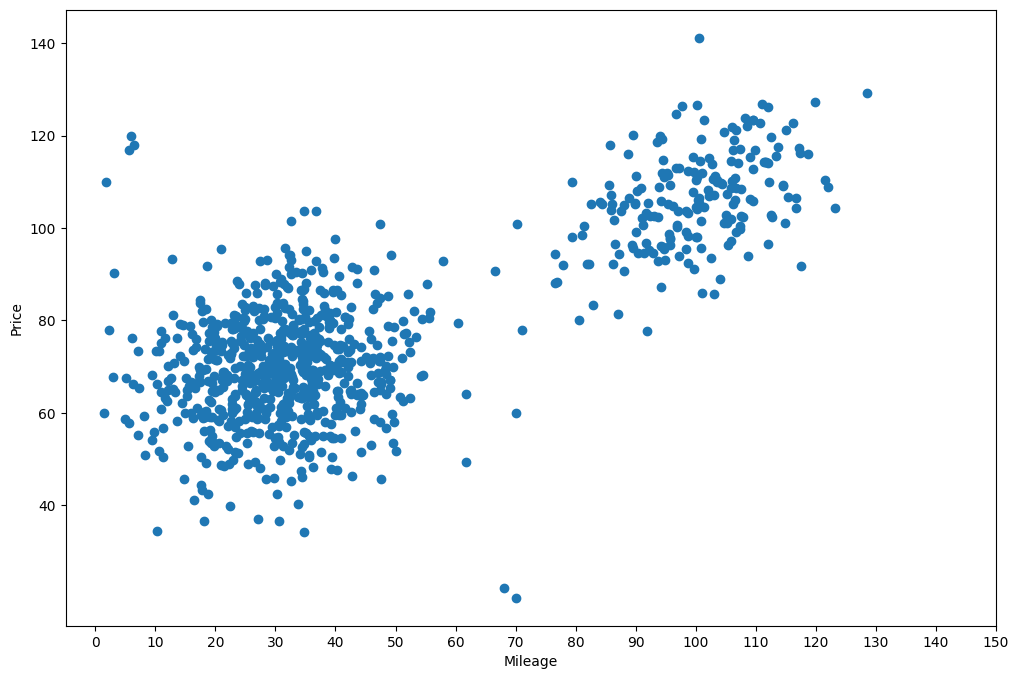

In [6]:
plt.scatter(df.Mileage, df.Price)
plt.yticks(np.arange(40,160,20))
plt.xticks(np.arange(0,160,10))
plt.xlabel('Mileage')
plt.ylabel('Price')

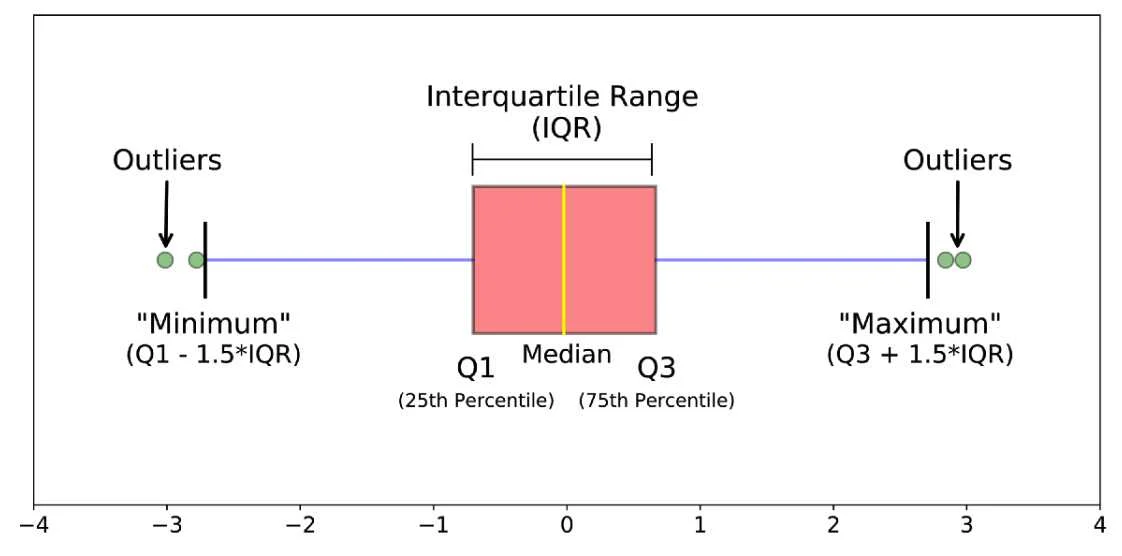![image.png](
  

)

In [7]:
import numpy as np
def outlier_indices(x):
    Q1, Q3 = np.percentile(x, [25, 75])
    IQR = Q3-Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    outlier_index = np.where((x < lower_bound) | (x > upper_bound))
    return outlier_index

In [8]:
a = [1,123,234,234,2,3,345,34,234,5,3423,4234]
np.percentile(a,25)

np.float64(4.5)

In [9]:
import numpy as np
from sklearn.covariance import EllipticEnvelope

In [11]:
elpenv = EllipticEnvelope(contamination=0.025,  # setting our contamination parameter
                          random_state=1)

In [12]:
pred = elpenv.fit_predict(df) # saving predictions in a variable pred

In [13]:
df['is_outlier_ee'] = pred

In [14]:
df

,Mileage,Price,is_outlier_ee
0,54.282388,67.967708,1
1,17.331911,70.023637,1
2,36.548113,68.080455,1
3,42.567541,71.058755,1
4,5.608853,57.822432,1
...,...,...,...
903,5.584939,117.000000,1
904,70.000000,20.000000,1
905,68.000000,22.000000,1
906,70.000000,60.000000,1


In [15]:
df[df['is_outlier_ee']==-1] #outliers

,Mileage,Price,is_outlier_ee
713,112.123218,126.304762,-1
718,117.382482,116.340676,-1
741,116.756890,104.381785,-1
742,121.593860,110.415852,-1
753,122.140478,108.911361,-1
776,117.253947,117.246955,-1
786,113.809389,117.468742,-1
791,100.495158,141.201890,-1
802,117.648921,91.709090,-1
810,116.175878,122.733600,-1


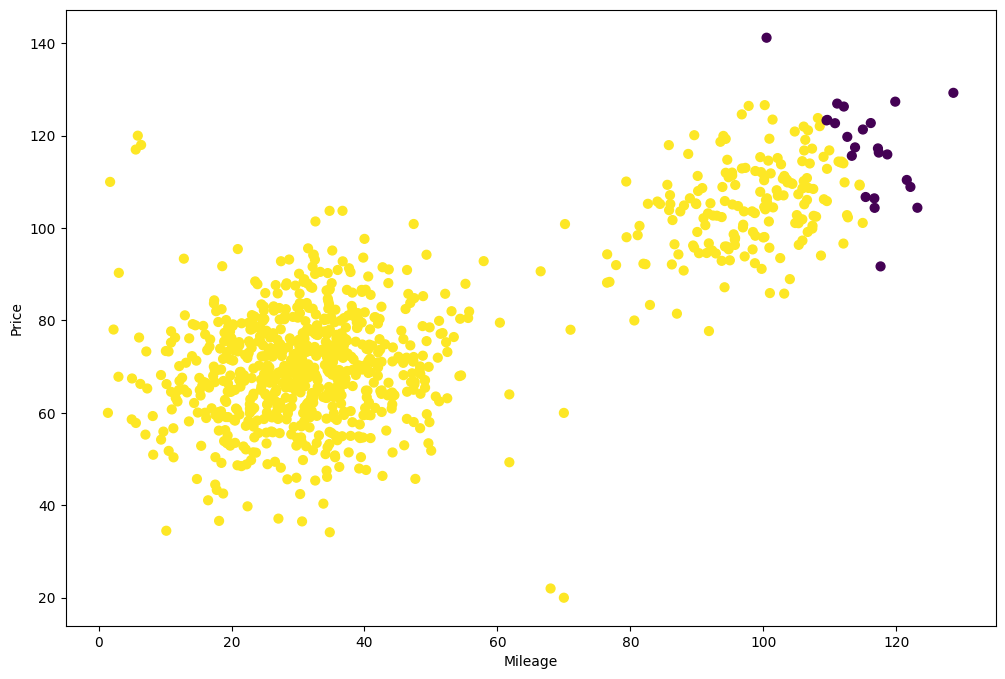

In [16]:
plt.scatter(df.Mileage, df.Price, s=40, c=df['is_outlier_ee'])
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

In [17]:
from sklearn.ensemble import IsolationForest

In [18]:
df= df.drop('is_outlier_ee', axis=1)

In [19]:
df

,Mileage,Price
0,54.282388,67.967708
1,17.331911,70.023637
2,36.548113,68.080455
3,42.567541,71.058755
4,5.608853,57.822432
...,...,...
903,5.584939,117.000000
904,70.000000,20.000000
905,68.000000,22.000000
906,70.000000,60.000000


In [33]:
clf = IsolationForest(random_state=0, contamination = 0.02).fit_predict(df)
df['is_outlier_if'] = clf

In [34]:
df

,Mileage,Price,is_outlier_if
0,54.282388,67.967708,1
1,17.331911,70.023637,1
2,36.548113,68.080455,1
3,42.567541,71.058755,1
4,5.608853,57.822432,1
...,...,...,...
903,5.584939,117.000000,-1
904,70.000000,20.000000,-1
905,68.000000,22.000000,-1
906,70.000000,60.000000,-1


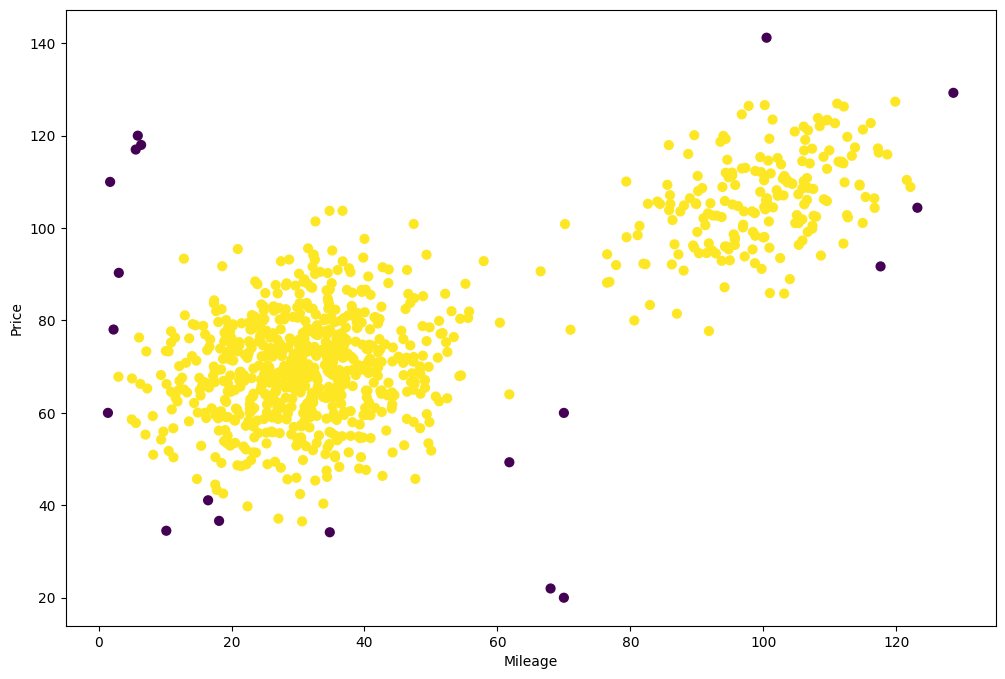

In [35]:
plt.scatter(df.Mileage, df.Price, s=40, c=df['is_outlier_if'])
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

In [36]:
df=df.drop('is_outlier_if',axis=1)

In [37]:
from sklearn.neighbors import LocalOutlierFactor

# using same data that we used in Elliptical Envelope -----> df

outlier_scores = LocalOutlierFactor(n_neighbors=20, contamination=0.025).fit_predict(df)

In [38]:
df['is_outlier_lof'] = outlier_scores

In [39]:
df

,Mileage,Price,is_outlier_lof
0,54.282388,67.967708,1
1,17.331911,70.023637,1
2,36.548113,68.080455,1
3,42.567541,71.058755,1
4,5.608853,57.822432,1
...,...,...,...
903,5.584939,117.000000,-1
904,70.000000,20.000000,-1
905,68.000000,22.000000,-1
906,70.000000,60.000000,-1


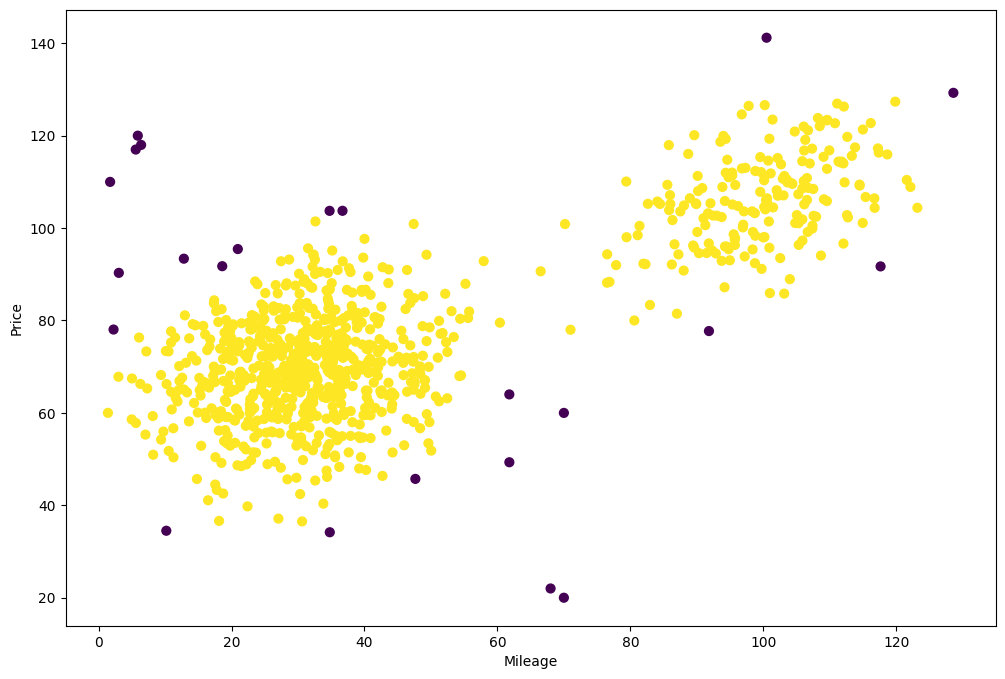

In [40]:
plt.scatter(df.Mileage, df.Price, s=40, c=df['is_outlier_lof'])
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()